# Mark 4E — Checkpoint-Fusion Validation Gate

## tl;dr

Mark 4D found complementary validation behavior: the control checkpoint retains V116 response, while recall-loss improves positive-slice recall, V104 and Q1 detection. This notebook tests whether fixed probability-level fusion can satisfy all six temporary validation targets without retraining.

It reuses the frozen Mark 4D probability caches. It performs no model training or test evaluation.

## Context & Methods

### Fusion policies

- control only;
- recall-loss only;
- pixelwise maximum;
- equal arithmetic mean;
- 75% control + 25% recall;
- 25% control + 75% recall;
- geometric mean.

Every policy is evaluated across the same threshold grid from 0.05 to 0.70. Mean patient Dice uses only the nine tumour-positive validation patients. Empty-slice false positives continue to use all tumour-empty slices.

### Decision contract

A fusion policy must pass all six targets. If several pass, choose the highest positive-patient mean Dice, then the lower empty-slice false-positive rate. Passing authorizes only a bounded validation continuation/freeze check—not test access.

In [1]:
from __future__ import annotations
from pathlib import Path
from IPython.display import display
import hashlib,json,warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

warnings.filterwarnings('ignore',category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')
PROJECT_ROOT=Path(r'D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver')
DATASET_ROOT=Path('D:/DATA SCIENCE AND ANALYTICS/Dataset/Liver/02_staging/build_corrected_20260713_214847_v2')
MANIFEST_PATH=DATASET_ROOT/'manifests'/'slice_manifest.csv'
MARK4D_DIR=PROJECT_ROOT/'mark 1'/'mark_4d_outputs'
CACHE_DIR=MARK4D_DIR/'probability_cache'
OUTPUT_DIR=PROJECT_ROOT/'mark 1'/'mark_4e_outputs'; OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
EXPECTED_MANIFEST_SHA256='575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889'
THRESHOLDS=np.array([.05,.10,.15,.20,.25,.30,.35,.40,.45,.50,.55,.60,.65,.70],dtype=np.float32)
TARGETS={'mean_patient_dice':.3329,'volume_104_dice':.05,'volume_116_dice':.01,'q1_detected_pct':35.,'positive_predicted_empty_pct':35.,'empty_slice_false_positive_pct':20.}
POLICIES=['control','recall_loss','maximum','mean','control75_recall25','control25_recall75','geometric_mean']
print('Outputs:',OUTPUT_DIR)

Outputs: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\mark 1\mark_4e_outputs


## Data

### 1. Verify Mark 4D provenance, cache alignment, and test lock

In [2]:
def sha256_file(path):
    d=hashlib.sha256()
    with Path(path).open('rb') as h:
        for chunk in iter(lambda:h.read(1024*1024),b''): d.update(chunk)
    return d.hexdigest()

assert sha256_file(MANIFEST_PATH)==EXPECTED_MANIFEST_SHA256
mark4d=json.loads((MARK4D_DIR/'mark_4d_gate_result.json').read_text())
provenance4d=json.loads((MARK4D_DIR/'mark_4d_provenance.json').read_text())
assert mark4d['test_images_accessed'] is False and provenance4d['test_images_accessed'] is False
cache_paths={name:{int(p.stem.split('_')[-1]):p for p in (CACHE_DIR/name).glob('volume_*.npz')} for name in ['control','recall_loss']}
assert set(cache_paths['control'])==set(cache_paths['recall_loss']) and len(cache_paths['control'])==13
for vid in cache_paths['control']:
    with np.load(cache_paths['control'][vid],allow_pickle=False) as c, np.load(cache_paths['recall_loss'][vid],allow_pickle=False) as r:
        assert c.files==r.files and c['probability'].shape==r['probability'].shape
        assert np.array_equal(c['truth'],r['truth']) and np.array_equal(c['slice_index'],r['slice_index'])

manifest=pd.read_csv(MANIFEST_PATH); val_rows=manifest.loc[manifest.split.eq('val')]
positive_volumes=sorted(val_rows.loc[val_rows.tumor_pixels.gt(0),'volume_id'].unique().tolist())
q1_limit=val_rows.loc[val_rows.tumor_pixels.gt(0),'tumor_pixels'].quantile(.25)
assert len(positive_volumes)==9
provenance={'manifest_sha256':EXPECTED_MANIFEST_SHA256,'mark_4d_gate_sha256':sha256_file(MARK4D_DIR/'mark_4d_gate_result.json'),'policies':POLICIES,'thresholds':THRESHOLDS.tolist(),'positive_patient_definition':positive_volumes,'test_images_accessed':False}
(OUTPUT_DIR/'mark_4e_provenance.json').write_text(json.dumps(provenance,indent=2))
print('PASS: cache pairs aligned for 13 volumes; nine positive patients; test remains locked.')

PASS: cache pairs aligned for 13 volumes; nine positive patients; test remains locked.


### 2. Define fixed fusion policies and gate calculations

In [3]:
def fuse(control,recall,policy):
    if policy=='control': return control
    if policy=='recall_loss': return recall
    if policy=='maximum': return np.maximum(control,recall)
    if policy=='mean': return .5*control+.5*recall
    if policy=='control75_recall25': return .75*control+.25*recall
    if policy=='control25_recall75': return .25*control+.75*recall
    if policy=='geometric_mean': return np.sqrt(np.clip(control,0,1)*np.clip(recall,0,1))
    raise KeyError(policy)

def passes(row):
    return {key:(row[key]<=target if key in ['positive_predicted_empty_pct','empty_slice_false_positive_pct'] else row[key]>=target) for key,target in TARGETS.items()}

## Results

### 3. Evaluate fusion policies over the complete validation population

In [4]:
acc={(policy,float(t)):{'patients':{},'positive_empty':[],'empty_fp':[],'q1':[]} for policy in POLICIES for t in THRESHOLDS}
slice_rows=[]
for vid in sorted(cache_paths['control']):
    with np.load(cache_paths['control'][vid],allow_pickle=False) as c, np.load(cache_paths['recall_loss'][vid],allow_pickle=False) as r:
        control=c['probability'].astype(np.float32); recall=r['probability'].astype(np.float32); truth=c['truth'].astype(bool)
        truth_pixels=truth.sum(axis=(1,2)); positive=truth_pixels>0; empty=~positive; q1=positive&(truth_pixels<=q1_limit)
        for policy in POLICIES:
            probability=fuse(control,recall,policy)
            for threshold in THRESHOLDS:
                pred=probability>=threshold; key=(policy,float(threshold)); a=acc[key]
                a['patients'][vid]=(2*(pred&truth).sum()+1e-6)/(pred.sum()+truth.sum()+1e-6)
                pred_pixels=pred.sum(axis=(1,2)); detected=(pred&truth).any(axis=(1,2))
                a['positive_empty'].extend(pred_pixels[positive]==0); a['empty_fp'].extend(pred_pixels[empty]>0); a['q1'].extend(detected[q1])
            if policy in ['control','recall_loss','maximum','control75_recall25']:
                pred=probability>=.5; detected=(pred&truth).any(axis=(1,2))
                for i in np.where(positive)[0]: slice_rows.append({'policy':policy,'volume_id':vid,'slice_index':int(c['slice_index'][i]),'sample_id':str(c['sample_id'][i]),'truth_pixels':int(truth_pixels[i]),'detected':bool(detected[i]),'max_truth_probability':float(probability[i][truth[i]].max())})

rows=[]; patient_rows=[]
for (policy,threshold),a in acc.items():
    row={'policy':policy,'threshold':threshold,'mean_patient_dice':float(np.mean([a['patients'][v] for v in positive_volumes])),'volume_104_dice':a['patients'][104],'volume_116_dice':a['patients'][116],'q1_detected_pct':100*np.mean(a['q1']),'positive_predicted_empty_pct':100*np.mean(a['positive_empty']),'empty_slice_false_positive_pct':100*np.mean(a['empty_fp'])}
    status=passes(row); row['targets_passed']=sum(status.values()); row['all_targets_passed']=all(status.values()); rows.append(row)
    for vid,dice in a['patients'].items(): patient_rows.append({'policy':policy,'threshold':threshold,'volume_id':vid,'has_tumor':vid in positive_volumes,'dice':dice})
results=pd.DataFrame(rows); patients=pd.DataFrame(patient_rows); slices=pd.DataFrame(slice_rows)
results.to_csv(OUTPUT_DIR/'fusion_threshold_results.csv',index=False); patients.to_csv(OUTPUT_DIR/'fusion_patient_metrics.csv',index=False); slices.to_csv(OUTPUT_DIR/'fusion_positive_slice_diagnostic.csv',index=False)
best_by_policy=results.sort_values(['all_targets_passed','targets_passed','mean_patient_dice','empty_slice_false_positive_pct'],ascending=[False,False,False,True]).groupby('policy',as_index=False).first().sort_values(['all_targets_passed','targets_passed','mean_patient_dice'],ascending=False)
best_by_policy.to_csv(OUTPUT_DIR/'best_configuration_by_policy.csv',index=False); display(best_by_policy)

,policy,threshold,mean_patient_dice,volume_104_dice,volume_116_dice,q1_detected_pct,positive_predicted_empty_pct,empty_slice_false_positive_pct,targets_passed,all_targets_passed
4,maximum,0.70,0.377087,0.116627,1.047355e-02,50.570342,27.447217,5.548066,6,True
5,mean,0.35,0.374802,0.117639,1.047181e-02,50.570342,27.447217,5.548066,6,True
2,control75_recall25,0.20,0.367569,0.119050,1.237261e-02,50.570342,27.351248,5.537696,6,True
1,control25_recall75,0.20,0.366512,0.130283,1.016657e-02,50.570342,26.583493,5.724360,6,True
6,recall_loss,0.60,0.376588,0.100240,7.116977e-04,47.908745,30.518234,4.791040,5,False
0,control,0.65,0.365442,0.063130,1.020738e-02,42.585551,37.044146,3.391061,5,False
3,geometric_mean,0.25,0.370786,0.050336,6.528438e-12,40.304183,40.978887,2.519963,4,False


### 4. Select the complete-gate winner

In [5]:
eligible=results.loc[results.all_targets_passed]
if eligible.empty:
    selected=results.sort_values(['targets_passed','mean_patient_dice','empty_slice_false_positive_pct'],ascending=[False,False,True]).iloc[0]; full_pass=False
else:
    selected=eligible.sort_values(['mean_patient_dice','empty_slice_false_positive_pct'],ascending=[False,True]).iloc[0]; full_pass=True
selected_passes=passes(selected)
selection=pd.DataFrame([{'metric':key,'actual':selected[key],'target':target,'direction':'<=' if key in ['positive_predicted_empty_pct','empty_slice_false_positive_pct'] else '>=','passed':selected_passes[key]} for key,target in TARGETS.items()])
selection.to_csv(OUTPUT_DIR/'selected_gate_table.csv',index=False)
print('Selected:',selected.policy,'threshold',selected.threshold,'| full pass:',full_pass); display(selection)

Selected: maximum threshold 0.699999988079071 | full pass: True


,metric,actual,target,direction,passed
0,mean_patient_dice,0.377087,0.3329,>=,True
1,volume_104_dice,0.116627,0.0500,>=,True
2,volume_116_dice,0.010474,0.0100,>=,True
3,q1_detected_pct,50.570342,35.0000,>=,True
4,positive_predicted_empty_pct,27.447217,35.0000,<=,True
5,empty_slice_false_positive_pct,5.548066,20.0000,<=,True


### 5. Visualize fusion frontiers and patient effects

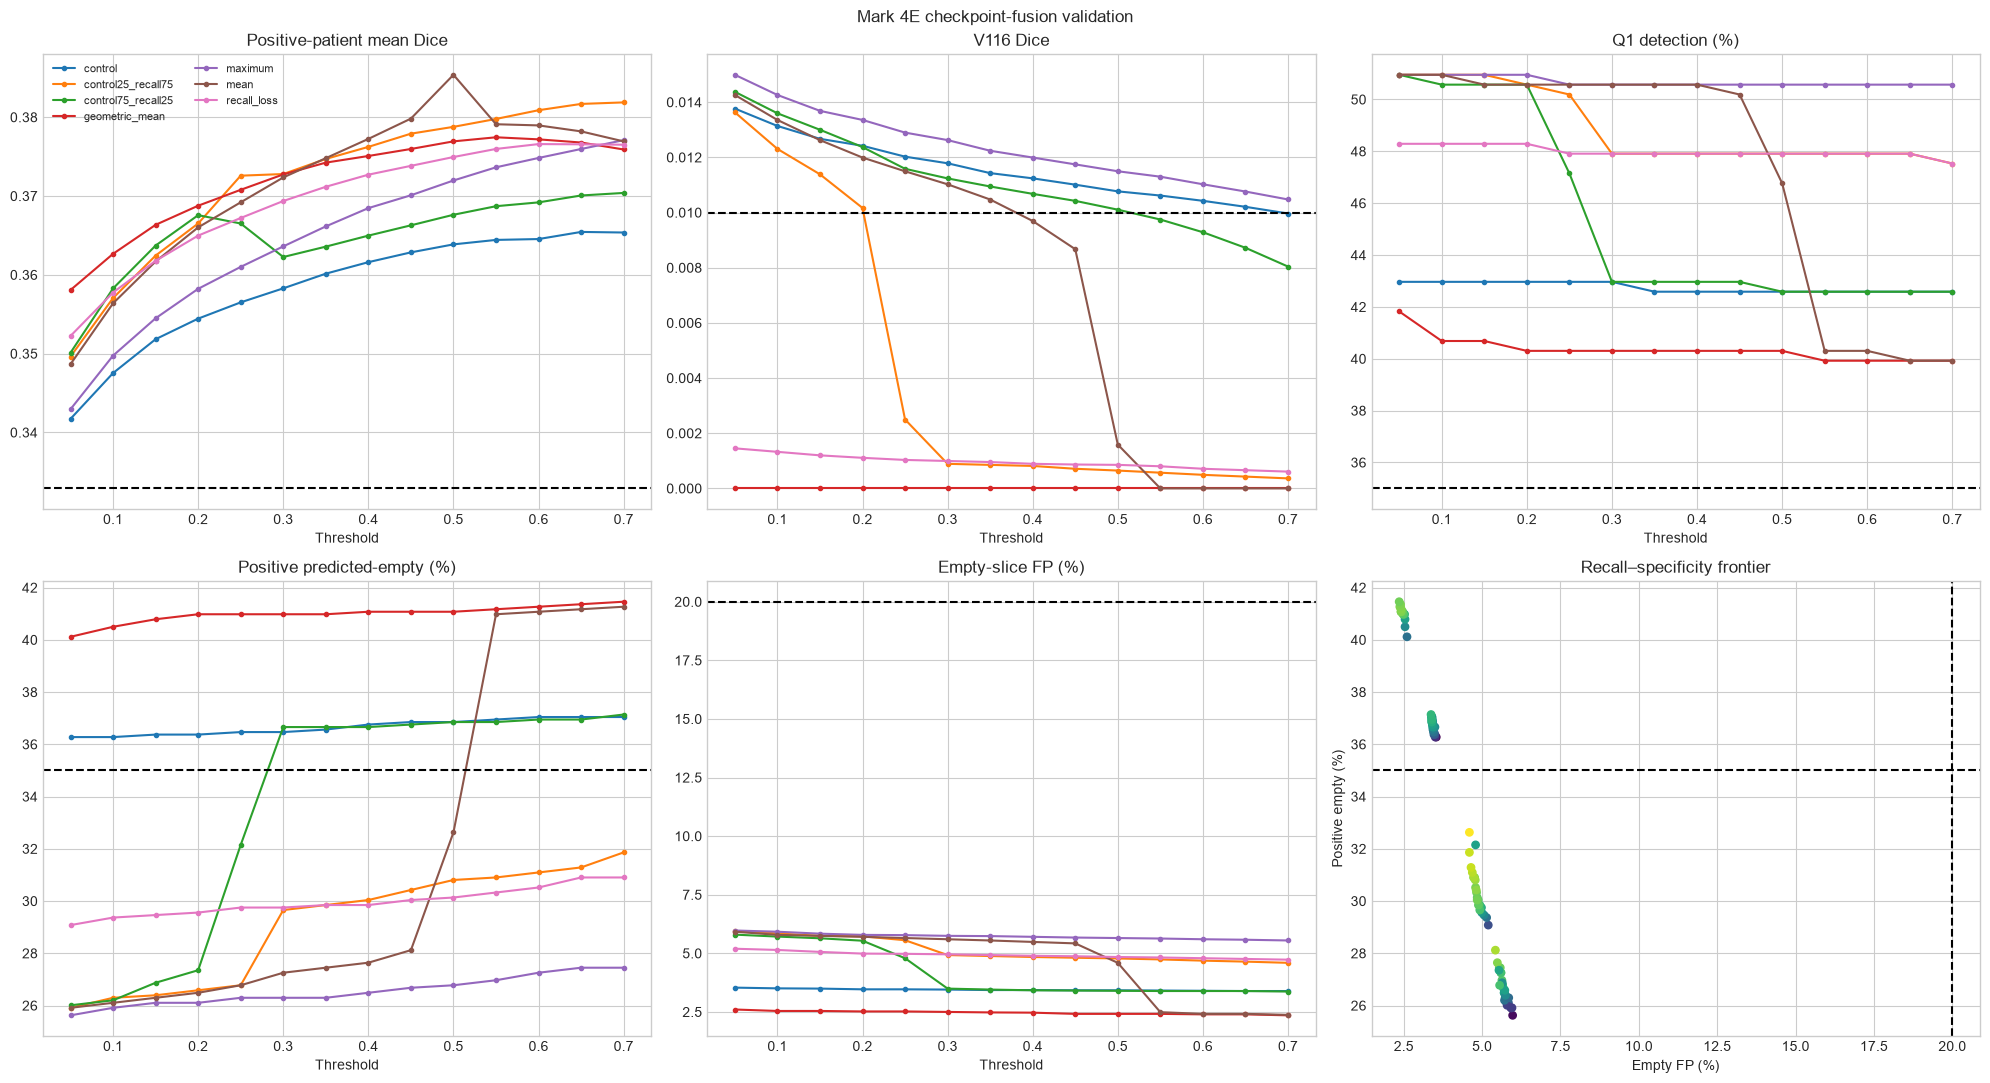

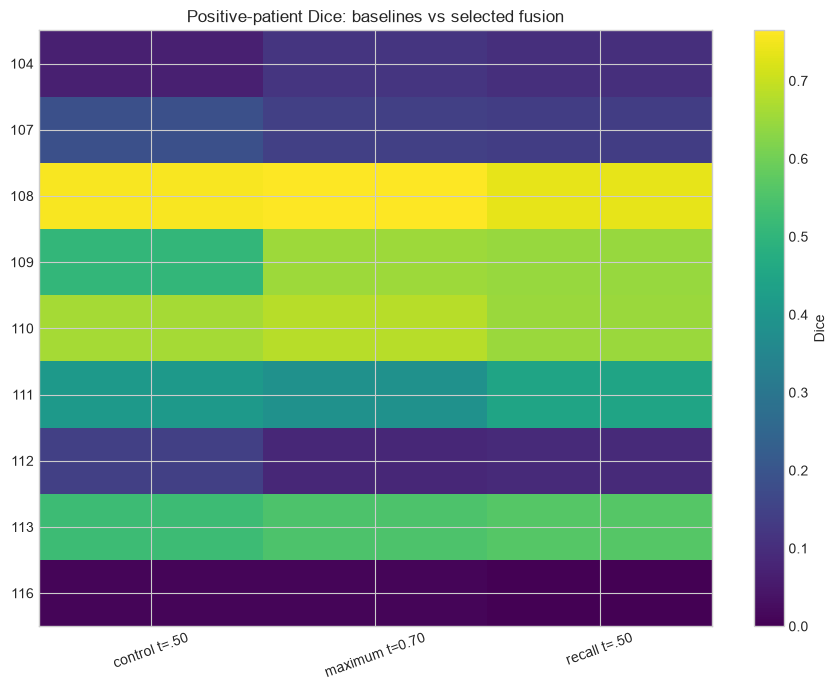

In [6]:
fig,axes=plt.subplots(2,3,figsize=(20,11))
fields=[('mean_patient_dice','Positive-patient mean Dice',.3329),('volume_116_dice','V116 Dice',.01),('q1_detected_pct','Q1 detection (%)',35),('positive_predicted_empty_pct','Positive predicted-empty (%)',35),('empty_slice_false_positive_pct','Empty-slice FP (%)',20)]
for ax,(field,title,target) in zip(axes.ravel()[:5],fields):
    for policy,g in results.groupby('policy'): ax.plot(g.threshold,g[field],marker='o',ms=3,label=policy)
    ax.axhline(target,ls='--',c='black'); ax.set_title(title); ax.set_xlabel('Threshold')
axes[0,0].legend(fontsize=8,ncol=2)
axes[1,2].scatter(results.empty_slice_false_positive_pct,results.positive_predicted_empty_pct,c=results.mean_patient_dice,cmap='viridis',s=28); axes[1,2].axhline(35,ls='--',c='black'); axes[1,2].axvline(20,ls='--',c='black'); axes[1,2].set_xlabel('Empty FP (%)'); axes[1,2].set_ylabel('Positive empty (%)'); axes[1,2].set_title('Recall–specificity frontier')
fig.suptitle('Mark 4E checkpoint-fusion validation'); fig.tight_layout(); fig.savefig(OUTPUT_DIR/'fusion_validation_dashboard.png',dpi=170,bbox_inches='tight'); plt.show()

selected_patients=patients.loc[(patients.policy==selected.policy)&np.isclose(patients.threshold,selected.threshold)&patients.has_tumor]
control_patients=patients.loc[(patients.policy=='control')&np.isclose(patients.threshold,.5)&patients.has_tumor]
recall_patients=patients.loc[(patients.policy=='recall_loss')&np.isclose(patients.threshold,.5)&patients.has_tumor]
plot_data=pd.concat([control_patients.assign(configuration='control t=.50'),recall_patients.assign(configuration='recall t=.50'),selected_patients.assign(configuration=f'{selected.policy} t={selected.threshold:.2f}')])
pivot=plot_data.pivot(index='volume_id',columns='configuration',values='dice')
fig,ax=plt.subplots(figsize=(9,7)); im=ax.imshow(pivot.values,aspect='auto',cmap='viridis',vmin=0,vmax=max(.7,pivot.max().max())); ax.set_xticks(range(len(pivot.columns)),pivot.columns,rotation=20); ax.set_yticks(range(len(pivot.index)),pivot.index); ax.set_title('Positive-patient Dice: baselines vs selected fusion'); fig.colorbar(im,ax=ax,label='Dice'); fig.tight_layout(); fig.savefig(OUTPUT_DIR/'selected_fusion_patient_heatmap.png',dpi=170,bbox_inches='tight'); plt.show()

### 6. Inspect selected-fusion V116 localization

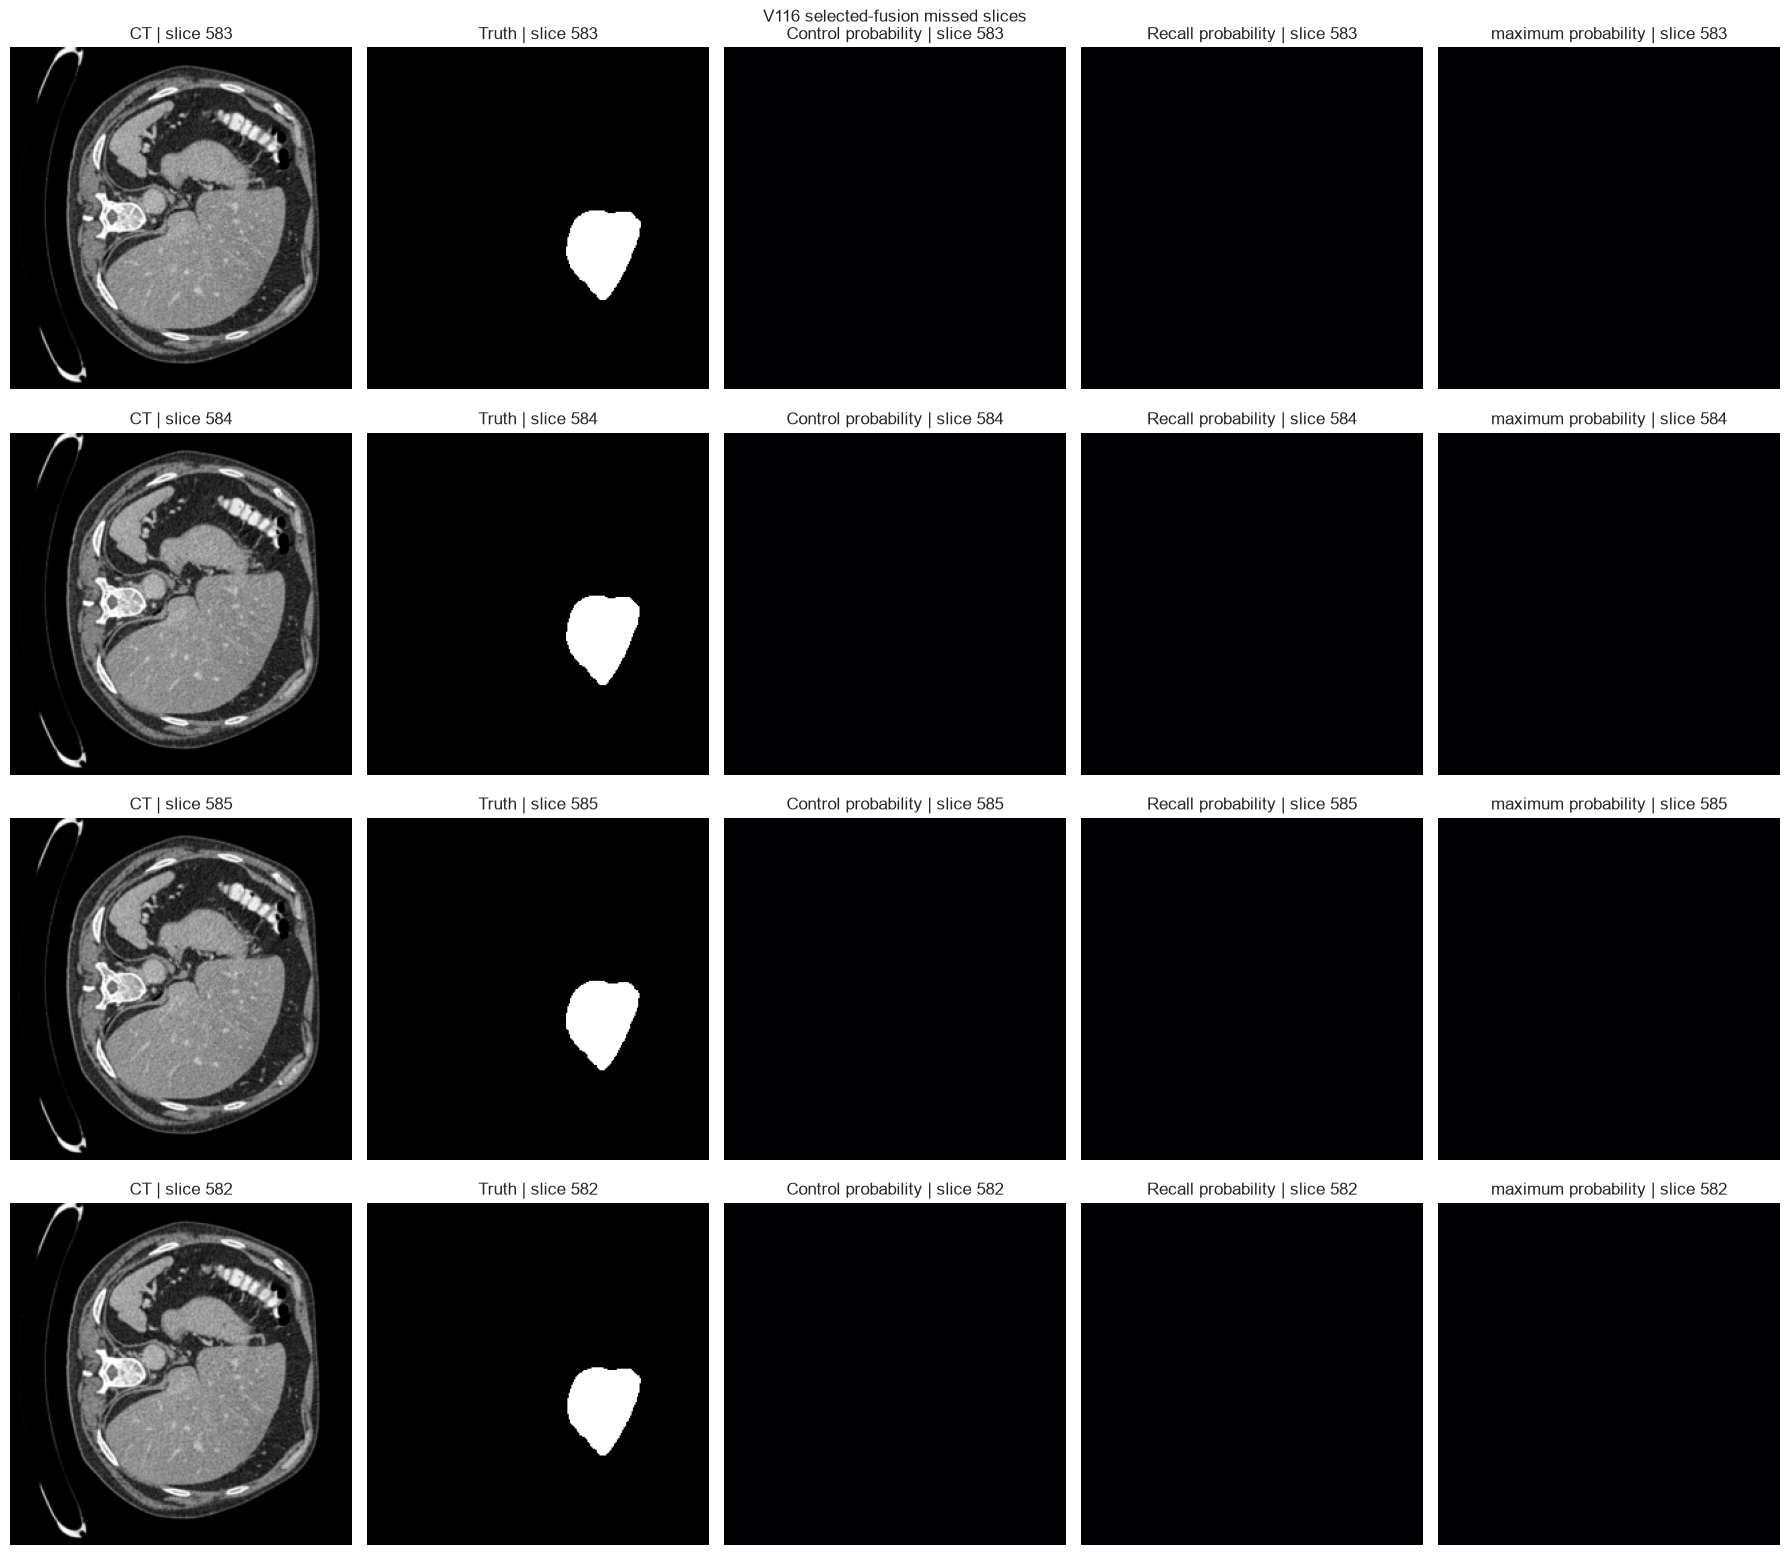

In [7]:
with np.load(cache_paths['control'][116],allow_pickle=False) as c, np.load(cache_paths['recall_loss'][116],allow_pickle=False) as r:
    probability=fuse(c['probability'].astype(np.float32),r['probability'].astype(np.float32),selected.policy); truth=c['truth'].astype(bool); pred=probability>=selected.threshold; truth_pixels=truth.sum(axis=(1,2)); detected=(pred&truth).any(axis=(1,2)); candidates=np.where((truth_pixels>0)&(~detected))[0]; focus=candidates[np.argsort(truth_pixels[candidates])[-4:]][::-1]
    lookup=val_rows.set_index('sample_id'); fig,axes=plt.subplots(len(focus),5,figsize=(18,4*len(focus)),squeeze=False)
    for row_axes,i in zip(axes,focus):
        sid=str(c['sample_id'][i]); row=lookup.loc[sid]
        with Image.open(DATASET_ROOT/row.image_path) as h: image=np.asarray(h.convert('L'),np.float32)/255
        panels=[(image,'CT','gray'),(truth[i],'Truth','gray'),(c['probability'][i],'Control probability','magma'),(r['probability'][i],'Recall probability','magma'),(probability[i],f'{selected.policy} probability','magma')]
        for ax,(panel,title,cmap) in zip(row_axes,panels): ax.imshow(panel,cmap=cmap,vmin=0,vmax=1); ax.set_title(f'{title} | slice {int(c["slice_index"][i])}'); ax.axis('off')
    fig.suptitle('V116 selected-fusion missed slices'); fig.tight_layout(); fig.savefig(OUTPUT_DIR/'selected_fusion_v116_localization.png',dpi=170,bbox_inches='tight'); plt.show()

### 7. Save the machine-readable decision

In [8]:
if full_pass:
    decision='FREEZE_FUSION_POLICY_AND_THRESHOLD'; next_notebook='mark_4f_fusion_freeze_and_bounded_confirmation'
else:
    decision='NO_FUSION_PASS_RUN_MODERATE_ALPHA_AND_HARD_POSITIVE_ABLATION'; next_notebook='mark_4f_targeted_training_ablation'
gate={'status':'mark_4e_fusion_pass' if full_pass else 'mark_4e_fusion_fail','selected_policy':str(selected.policy),'selected_threshold':float(selected.threshold),'selected_metrics':{key:float(selected[key]) for key in TARGETS},'targets_passed':int(selected.targets_passed),'decision':decision,'next_notebook':next_notebook,'metric_definition':'mean Dice over nine tumour-positive validation patients','manifest_sha256':EXPECTED_MANIFEST_SHA256,'test_images_accessed':False}
(OUTPUT_DIR/'mark_4e_gate_result.json').write_text(json.dumps(gate,indent=2)); print(json.dumps(gate,indent=2))

{
  "status": "mark_4e_fusion_pass",
  "selected_policy": "maximum",
  "selected_threshold": 0.699999988079071,
  "selected_metrics": {
    "mean_patient_dice": 0.3770866927494516,
    "volume_104_dice": 0.11662697526259982,
    "volume_116_dice": 0.010473553322754188,
    "q1_detected_pct": 50.57034220532319,
    "positive_predicted_empty_pct": 27.447216890595012,
    "empty_slice_false_positive_pct": 5.548065954578451
  },
  "targets_passed": 6,
  "decision": "FREEZE_FUSION_POLICY_AND_THRESHOLD",
  "next_notebook": "mark_4f_fusion_freeze_and_bounded_confirmation",
  "metric_definition": "mean Dice over nine tumour-positive validation patients",
  "manifest_sha256": "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889",
  "test_images_accessed": false
}


## Takeaways

- Treat the saved Mark 4E gate JSON as the authoritative fusion decision.
- A full pass freezes the exact checkpoint pair, fusion equation and threshold for a bounded confirmation run.
- If no fusion passes, do not search more arbitrary weights on this validation set. Proceed to one predeclared targeted training ablation.
- The test split remains locked until all validation gates pass and the complete inference policy is frozen.